In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
pd.set_option('display.max_columns', None)

In [5]:
df = pd.read_csv('gurgaon_properties_missing_value_imputation.csv')

In [6]:
df.shape

(3588, 19)

In [7]:
df.head()

,Unnamed: 0,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,0,flat,maa bhagwati residency,sector 7,0.45,5000.0,2.0,2.0,1,4.0,Relatively New,1000.0,0.0,0.0,0.0,0.0,0.0,1.0,28.0
1,1,flat,apna enclave,sector 3,0.50,7692.0,2.0,2.0,1,1.0,Old Property,722.0,0.0,0.0,0.0,0.0,0.0,0.0,37.0
2,3,flat,smart world orchard,sector 61,1.47,12250.0,2.0,2.0,2,2.0,New Property,1333.0,1.0,0.0,0.0,0.0,0.0,1.0,76.0
3,4,flat,parkwood westend,sector 92,0.70,5204.0,2.0,2.0,3,5.0,Under Construction,1217.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
4,5,flat,signature global infinity mall,sector 36,0.41,6269.0,2.0,2.0,3,3.0,New Property,654.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [8]:
train_df = df.drop(columns=['society','price_per_sqft'])

In [9]:
train_df.head()

,Unnamed: 0,property_type,sector,price,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,0,flat,sector 7,0.45,2.0,2.0,1,4.0,Relatively New,1000.0,0.0,0.0,0.0,0.0,0.0,1.0,28.0
1,1,flat,sector 3,0.50,2.0,2.0,1,1.0,Old Property,722.0,0.0,0.0,0.0,0.0,0.0,0.0,37.0
2,3,flat,sector 61,1.47,2.0,2.0,2,2.0,New Property,1333.0,1.0,0.0,0.0,0.0,0.0,1.0,76.0
3,4,flat,sector 92,0.70,2.0,2.0,3,5.0,Under Construction,1217.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
4,5,flat,sector 36,0.41,2.0,2.0,3,3.0,New Property,654.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


<Axes: >

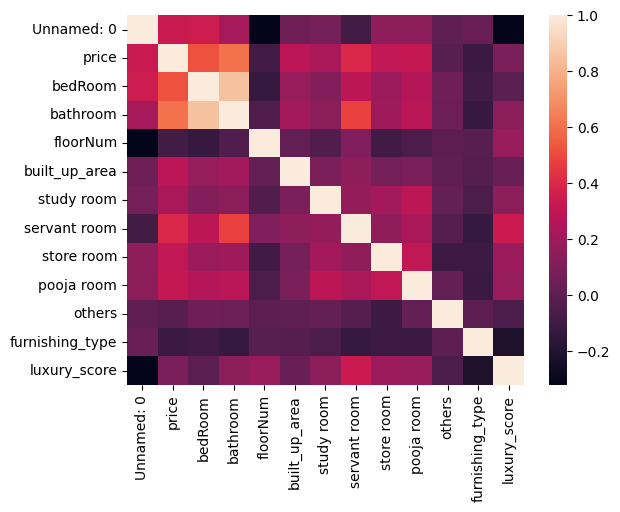

In [12]:
sns.heatmap(train_df.corr(numeric_only=True))

In [13]:
train_df.corr(numeric_only=True)['price'].sort_values(ascending=False)

price              1.000000
bathroom           0.603091
bedRoom            0.524919
servant room       0.394664
Unnamed: 0         0.333015
pooja room         0.321296
store room         0.306647
built_up_area      0.292238
study room         0.240559
luxury_score       0.097448
others            -0.012673
floorNum          -0.082909
furnishing_type   -0.114478
Name: price, dtype: float64

In [14]:
# cols in question

# numerical -> luxury_score, others, floorNum
# categorical -> property_type, sector, agePossession